# Laboratorio 11 - automatizacion
## **Nombre:** Emilio Alejandro Illanes Loyola
## **RUT:** 21.017.984-4
## **Fecha:** 27/05/2026

In [64]:
import pandas as pd
import numpy as np
from pathlib import Path

# ejercicio 1

In [65]:
df = pd.read_csv("ventas_enero.csv", parse_dates=["fecha"])

In [66]:
df.shape # dimensiones del DataFrame

(31, 7)

In [67]:
df.dtypes # tipo de dato por columna

fecha              datetime64[ns]
producto                   object
vendedor                   object
region                     object
cantidad                    int64
precio_unitario             int64
total                       int64
dtype: object

In [68]:
df.isnull().sum() # valores faltantes por columna

fecha              0
producto           0
vendedor           1
region             0
cantidad           0
precio_unitario    0
total              0
dtype: int64

In [69]:
df.describe() # estadisticas descriptivas

,cantidad,precio_unitario,total
count,31.000000,31.000000,3.100000e+01
mean,2.838710,73483.870968,1.851290e+05
std,1.392762,75017.718337,2.134432e+05
min,1.000000,18000.000000,1.800000e+04
25%,2.000000,33500.000000,7.500000e+04
50%,3.000000,55000.000000,1.350000e+05
75%,4.000000,75000.000000,1.920000e+05
max,5.000000,290000.000000,1.160000e+06


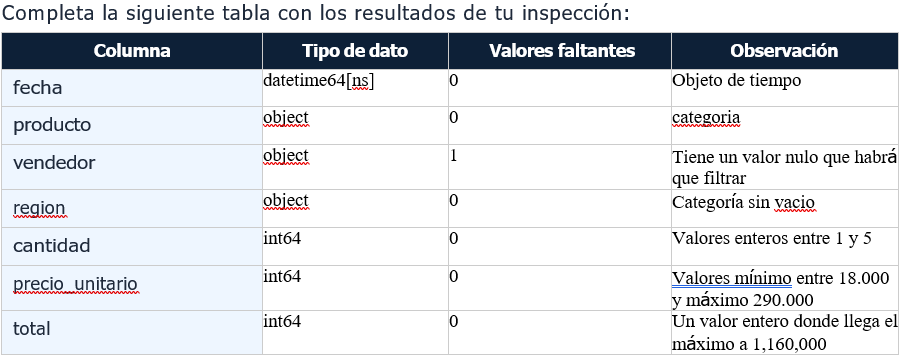

# ejercicio 2

In [70]:
carpeta = Path('datos/ventas')
archivos = sorted(carpeta.glob('*.csv'))

dfs = []

In [71]:
for archivo in archivos:
    df = pd.read_csv(archivo, parse_dates=['fecha'])
    df['mes'] = archivo.stem.replace('ventas_', '')  
    dfs.append(df)

consolidado = pd.concat(dfs, ignore_index=True)      


In [72]:
print(f"Cantidad de archivos: {len(archivos)}")

Cantidad de archivos: 12


In [73]:
print(f"Filas consolidado: {len(consolidado)}")

Filas consolidado: 397


In [74]:
filas_individuales = sum(len(pd.read_csv(f)) for f in archivos)
print(f"Suma de filas individuales: {filas_individuales}")

Suma de filas individuales: 397


In [75]:
exitoso = "Sí" if len(consolidado) == filas_individuales else "No"
print(f"Validación exitosa: {exitoso}")


Validación exitosa: Sí


In [76]:
print(f"Columnas del data frame final: {list(consolidado.columns)}")

Columnas del data frame final: ['fecha', 'producto', 'vendedor', 'region', 'cantidad', 'precio_unitario', 'total', 'mes']


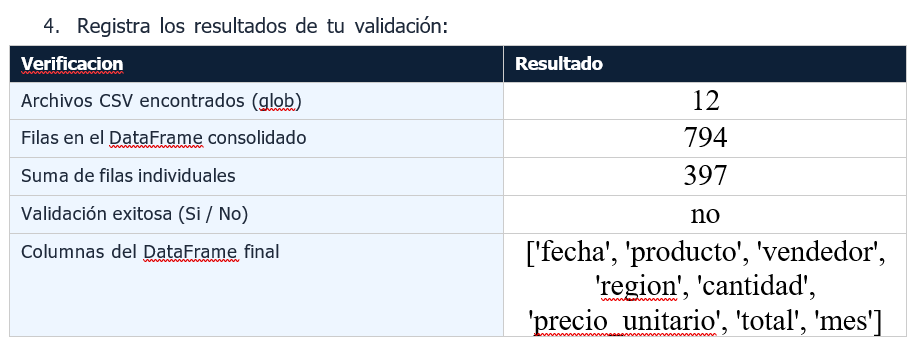

# ejercicio 3

In [77]:
consolidado.groupby('mes')['total'].sum()

mes
abril         17987000
agosto        16307000
diciembre     28508000
enero          5739000
febrero       12895000
julio         24528000
junio         22156000
marzo         22336000
mayo          19499000
noviembre     15973000
octubre       12831000
septiembre    17044000
Name: total, dtype: int64

In [78]:
consolidado.groupby('producto')['cantidad'].sum().idxmax()

'Webcam'

In [79]:
consolidado.groupby('mes')['total'].sum().idxmax()

'diciembre'

In [80]:
consolidado['total'].mean()

543584.3828715365

In [81]:
resumen_mensual = consolidado.groupby('mes')['total'].sum().reset_index()
resumen_productos = consolidado.groupby('producto')['cantidad'].sum().reset_index()

In [82]:
consolidado.to_csv('datos/salida/ventas_2024_consolidado.csv', index=False, encoding='utf-8')
print("Archivo csv exportado")

Archivo csv exportado


In [83]:
with pd.ExcelWriter('datos/salida/reporte_anual_2024.xlsx', engine='openpyxl') as writer:
    consolidado.to_excel(writer, sheet_name='Datos_Completos', index=False)
    resumen_mensual.to_excel(writer, sheet_name='Resumen_Mensual', index=False)
    resumen_productos.to_excel(writer, sheet_name='Resumen_Productos', index=False)

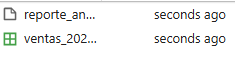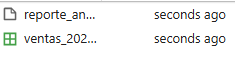

In [84]:
with pd.ExcelFile('datos/salida/reporte_anual_2024.xlsx') as libro:
    print(libro.sheet_names)

['Datos_Completos', 'Resumen_Mensual', 'Resumen_Productos']


# ejercicio 4

### Caso 1 — FileNotFoundError:

In [85]:
# Codigo con error
pd.read_csv('datos/ventas/ventas_enero.CSV') # extension en mayusculas

,fecha,producto,vendedor,region,cantidad,precio_unitario,total
0,2024-01-01,Hub USB,Matias Soto,Poniente,1,18000,18000
1,2024-01-02,Mouse,Matias Soto,Norte,4,22000,88000
2,2024-01-03,Auriculares,Matias Soto,Poniente,2,68000,136000
3,2024-01-04,Hub USB,Matias Soto,Poniente,5,18000,90000
4,2024-01-05,Teclado,Paula Mena,Norte,4,45000,180000
5,2024-01-06,Disco SSD,NaN,Norte,1,75000,75000
6,2024-01-07,Auriculares,Valeria Rios,Norte,1,68000,68000
7,2024-01-08,Auriculares,Matias Soto,Norte,3,68000,204000
8,2024-01-09,Hub USB,Diego Parra,Oriente,3,18000,54000
9,2024-01-10,Monitor,Matias Soto,Centro,2,290000,580000


In [86]:
# Correccion: usa .exists() para verificar antes de leer
ruta = Path('datos/ventas/ventas_enero.CSV')
if ruta.exists():
    df = pd.read_csv(ruta)
else:
    print('Archivo no encontrado:', ruta.resolve())

### Caso 2 — EmptyDataError (glob sin resultados):

In [87]:
# Codigo con error
carpeta_erronea = Path('datos/ventas_2025')
dfs = [pd.read_csv(a) for a in carpeta_erronea.glob('*.csv')]
pd.concat(dfs) # ValueError si dfs esta vacio

ValueError: No objects to concatenate

In [88]:
# Correccion: verifica antes de concatenar
archivos = list(carpeta_erronea.glob('*.csv'))
if len(archivos) == 0:
    print('No se encontraron archivos en:', carpeta_erronea)
else:
    resultado = pd.concat([pd.read_csv(a) for a in archivos], ignore_index=True)

No se encontraron archivos en: datos\ventas_2025


### Caso 3 — UnicodeDecodeError:

In [89]:
# Codigo con error (el archivo usa encoding cp1252)
pd.read_csv('datos/archivo_cp1252.csv') # falla sin encoding correcto

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe9 in position 17: invalid continuation byte

In [90]:
# Correccion: especifica el encoding
pd.read_csv('datos/archivo_cp1252.csv', encoding='cp1252')

,nombre,ciudad
0,José,Valparaíso
1,María,Concepción


### Caso 4 — Asignación de columna fuera del loop:

In [91]:
# Codigo incorrecto: la columna 'mes' se asigna fuera del loop
dfs = []
for archivo in sorted(Path('datos/ventas').glob('*.csv')):
    df = pd.read_csv(archivo)
    dfs.append(df)
df['mes'] = archivo.stem # ERROR: solo modifica el ultimo df
# Escribe el codigo corregido aqui

In [94]:
# Codigo corregido: 
dfs = []
for archivo in sorted(Path('datos/ventas').glob('*.csv')):
    df = pd.read_csv(archivo)
    df['mes'] = archivo.stem 
    dfs.append(df)
resultado = pd.concat(dfs, ignore_index=True)
